# [LAB-08] 2. 단변량 분석

## #01. 준비작업

### 1. 이전 분석 내용 가져오기

- 데이터 로드, 기초 통계량 가져오기 등의 반복적인 작업은 별도의 ipynb 파일에 구현해 두고 **Jupyter Magic Command**로 불러올 수 있다.
  - 다른 ipynb 파일의 소스코드를 이 위치에 복붙 하는 효과가 있다.
  - 가져온 ipynb 파일의 import 내용이나 변수들이 모두 유지된다.

In [8]:
%%capture cap

# 자신의 실습 환경에 맞게 파일 경로 수정하세요
%run "./[LAB-08] PBT - EDAㅣ1-EDA 시작하기(실습코드).ipynb"

### 2. 불러온 내용 확인

- 이전 분석 내역이 잘 로드 되었는지 확인한다.

In [9]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : MEDV
종속변수 유형: 연속형
연속형   : ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
명목형   : ['CHAS']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
CRIM,506.000,3.614,8.602,0.006,0.082,0.257,3.677,88.976,13.087,large_diff,3.595,9.070,-5.311,66,0.130,0,0.000,66,0.130,5.223,right tail,37.131,leptokurtic,log1p
ZN,506.000,11.364,23.322,0.000,0.000,0.000,12.500,100.000,inf,large_diff,12.500,31.250,-18.750,68,0.134,0,0.000,68,0.134,2.226,right tail,4.032,leptokurtic,log1p
INDUS,506.000,11.137,6.860,0.460,5.190,9.690,18.100,27.740,0.149,diff,12.910,37.465,-14.175,0,0.000,0,0.000,0,0.000,0.295,symmetric,-1.234,platykurtic,none
NOX,506.000,0.555,0.116,0.385,0.449,0.538,0.624,0.871,0.031,similar,0.175,0.886,0.187,0,0.000,0,0.000,0,0.000,0.729,right tail,-0.065,platykurtic,none
RM,506.000,6.285,0.703,3.561,5.885,6.208,6.623,8.780,0.012,similar,0.738,7.731,4.778,22,0.043,8,0.016,30,0.059,0.404,symmetric,1.892,leptokurtic,none


,CHAS
count,506
unique,2
top,0
freq,471


### 3. 라이브러리 참조하기

- 불러온 ipynb 파일에서 참조하지 않는 라이브러리중 필요한 것을 참조한다.
  - 여기서는 새로운 라이브러리의 참조는 불필요하지만,    
    라이브러리 참조 코드 위치를 제시하기 위해 이전 ipynb 파일과 중복 참조함

In [10]:
from helper import *

## #02. 종속변수의 단변량 분석

### 1. 연속형 변수에 대한 분석 수행

- 종속변수는 예측 대상이 되는 값이므로 가장 먼저 따로 시각화 한다.
- **단변량 점검의 목적**: "이 변수를 그대로 검정/모델에 넣어도 되는가?"를 판단한다.

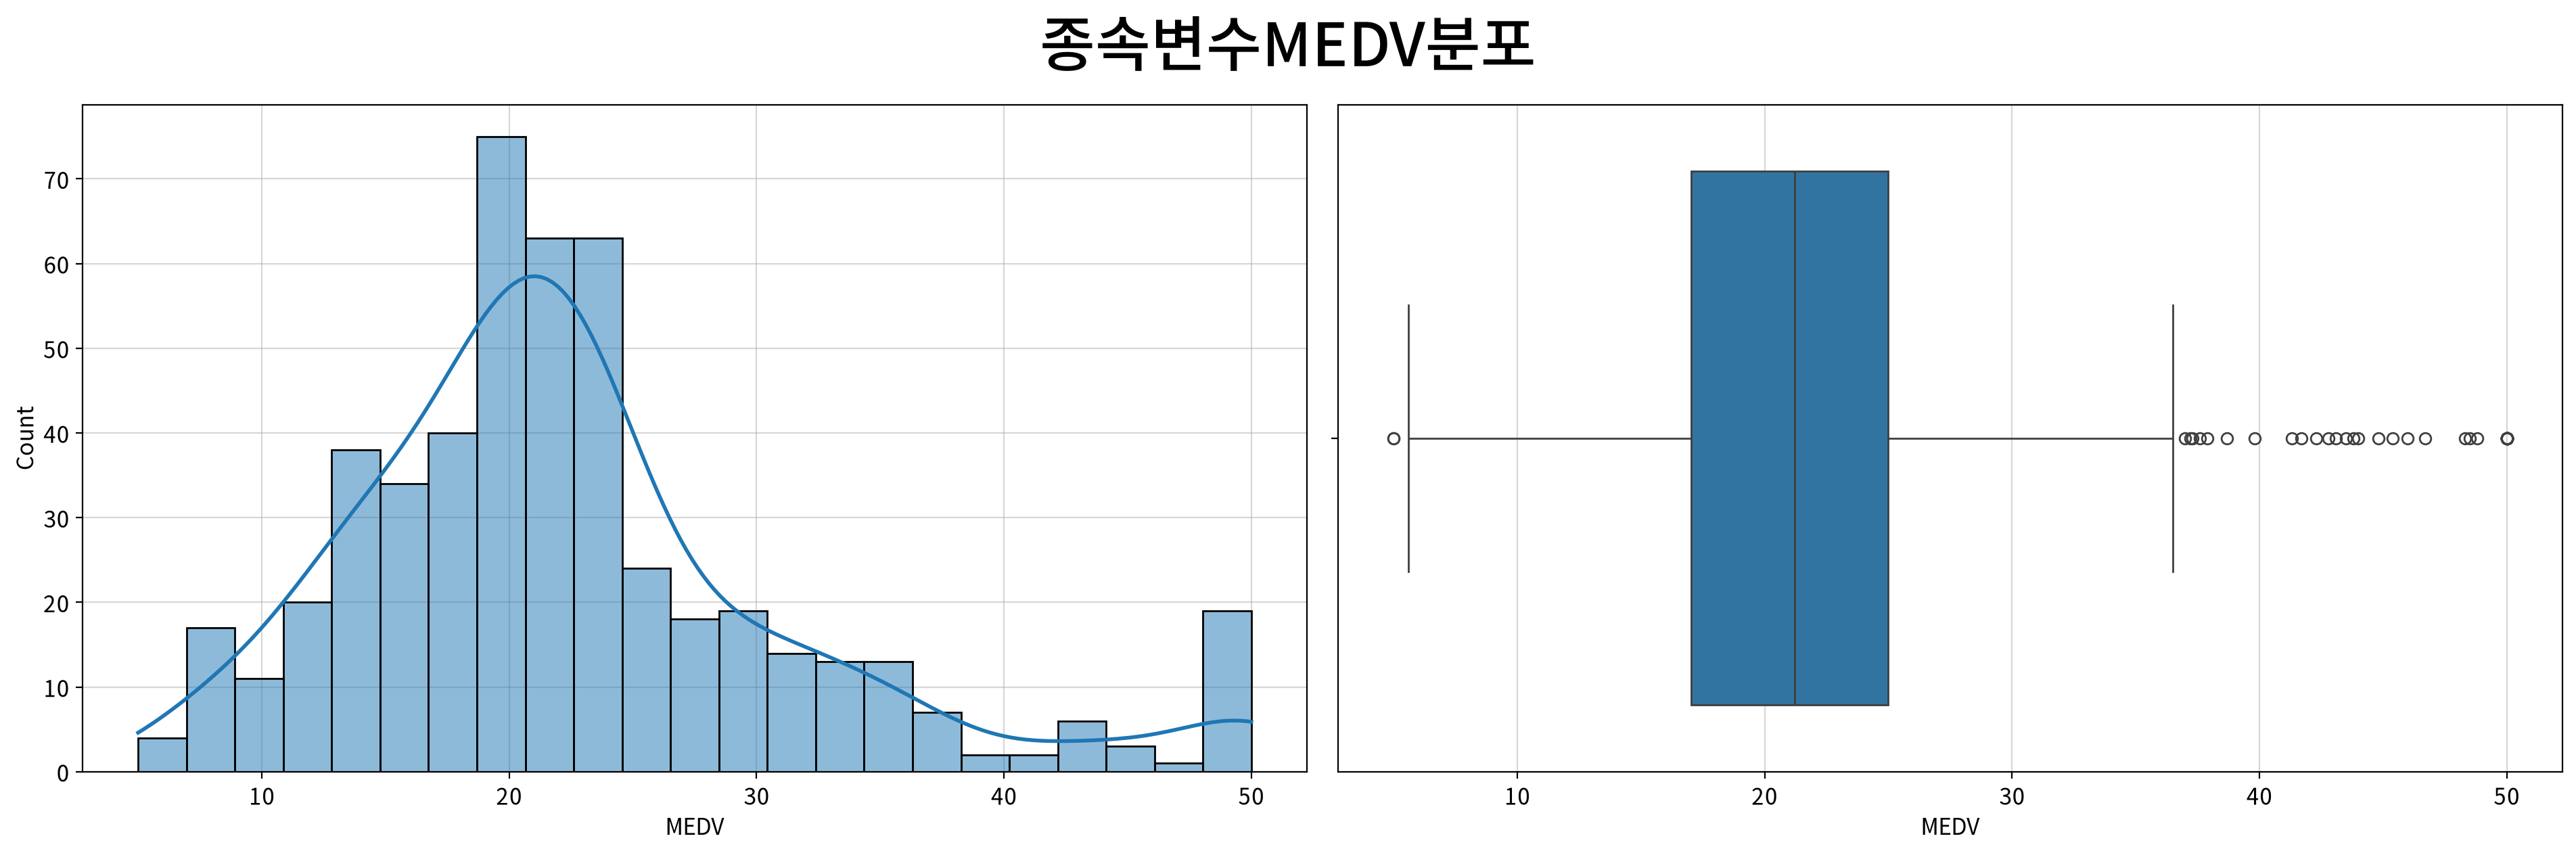

,MEDV
count,506.000
mean,22.533
std,9.197
min,5.000
25%,17.025
50%,21.200
75%,25.000
max,50.000
rel_diff,0.063
rdiff_flag,similar


In [12]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, title=f'종속변수{target}분포', width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
desc[desc.index == target].T

#### 💡 인사이트

| 점검 항목 | `MEDV` 관찰 내용 |
|---|---|
| 분포 모양(왜도) | 오른쪽으로 치우침(우편향, skew ≈ 1.1) |
| 봉우리 수 | 단봉 — 단, 오른쪽 끝(50)에 인위적 군집 |
| 이상치 | 위쪽 수염 밖에 점 존재(상위 약 8%) |
| 이산점(군집) | 50에 값이 뭉침 = 상한 처리(천장효과) |

**판단·조치**: 우편향 + 50 천장효과가 있어 그대로 쓰기엔 부담스럽다. → **로그 변환**으로 분포를 좌우 대칭에 가깝게 펴고, 50에 잘린 값(천장효과)은 높은 가격대 예측의 한계로 인지한다.

## #03. 독립변수의 단변량 분석

### 1. 연속형 독립변수

- 각 변수를 **분포 모양(왜도) · 봉우리 수 · 이상치(박스플롯 점) · 이산점(군집)** 관점에서 점검하여 "그대로 검정/모델에 넣어도 되는가?"를 판단한다.

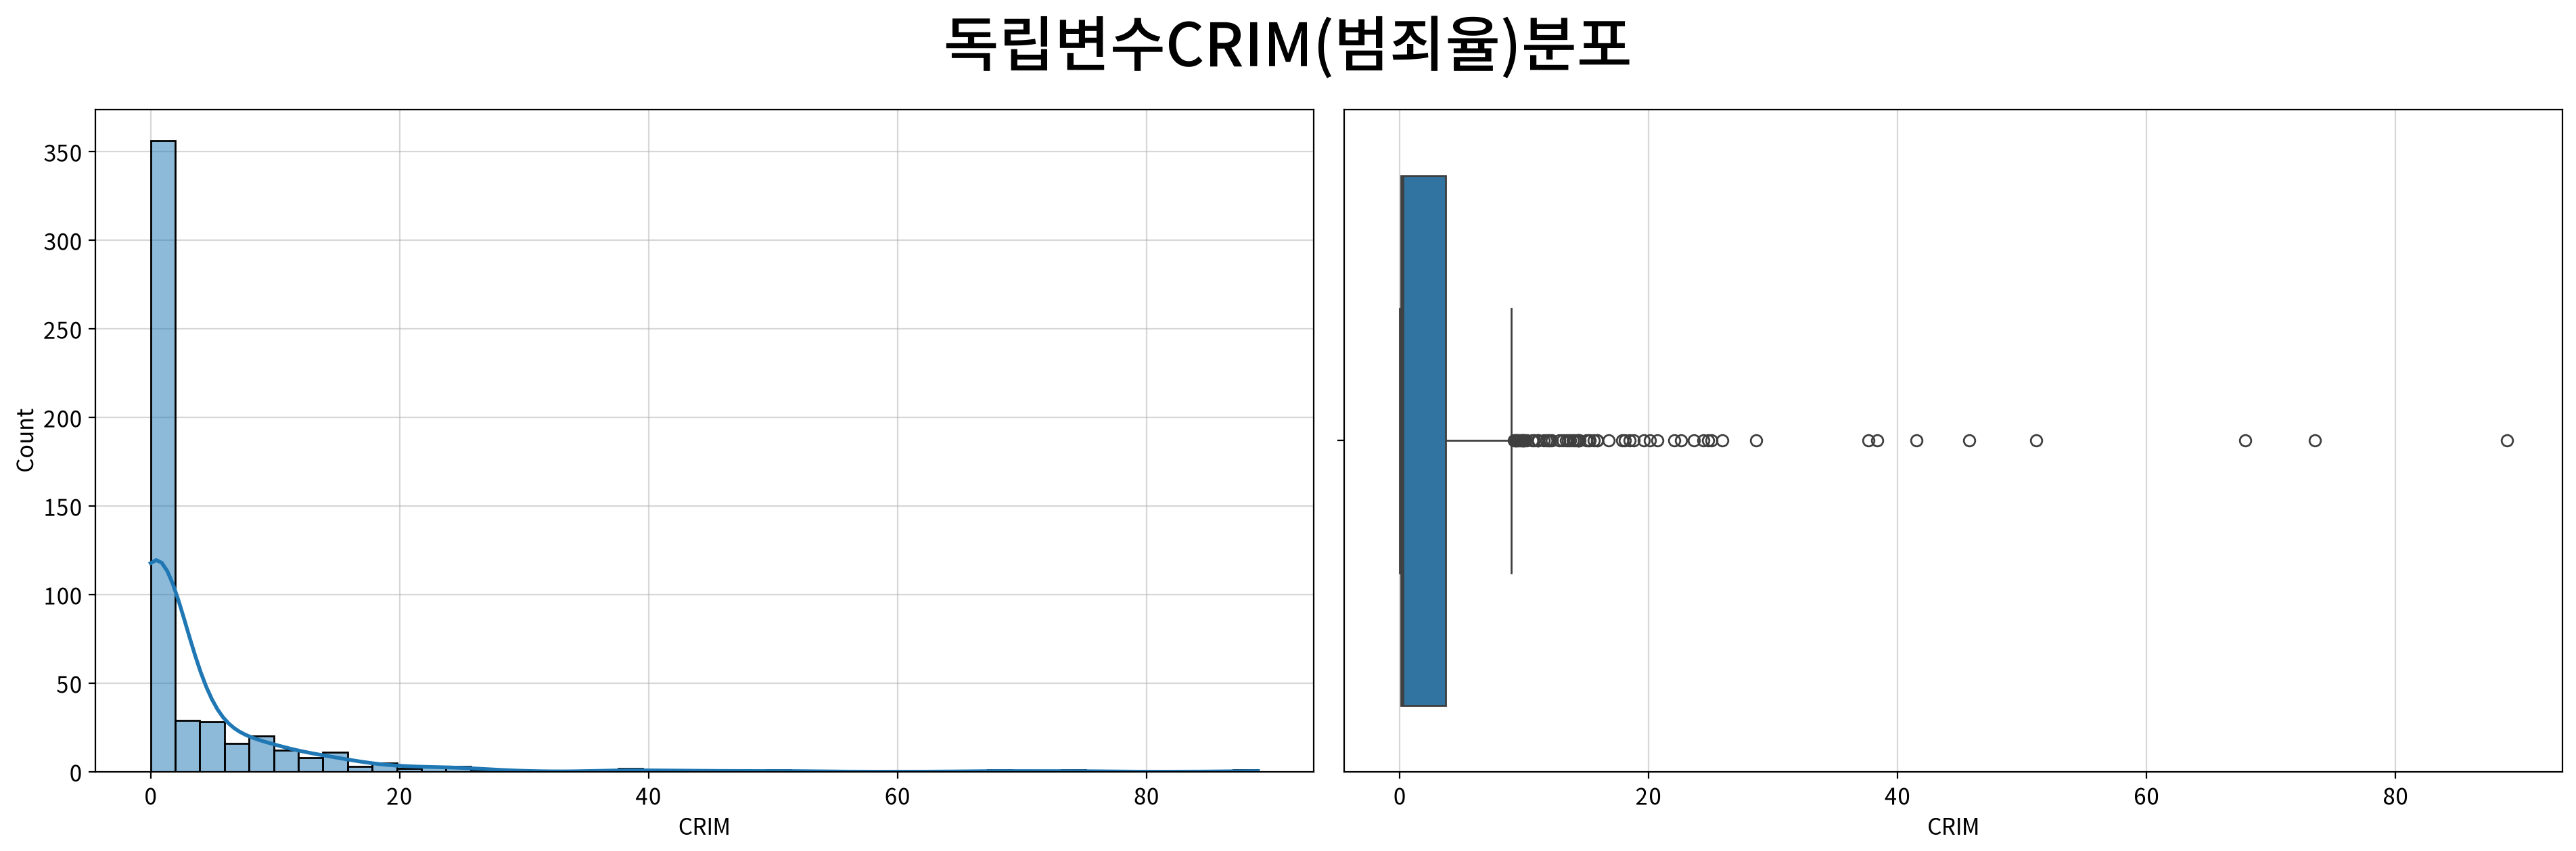

,CRIM
count,506.000
mean,3.614
std,8.602
min,0.006
25%,0.082
50%,0.257
75%,3.677
max,88.976
rel_diff,13.087
rdiff_flag,large_diff


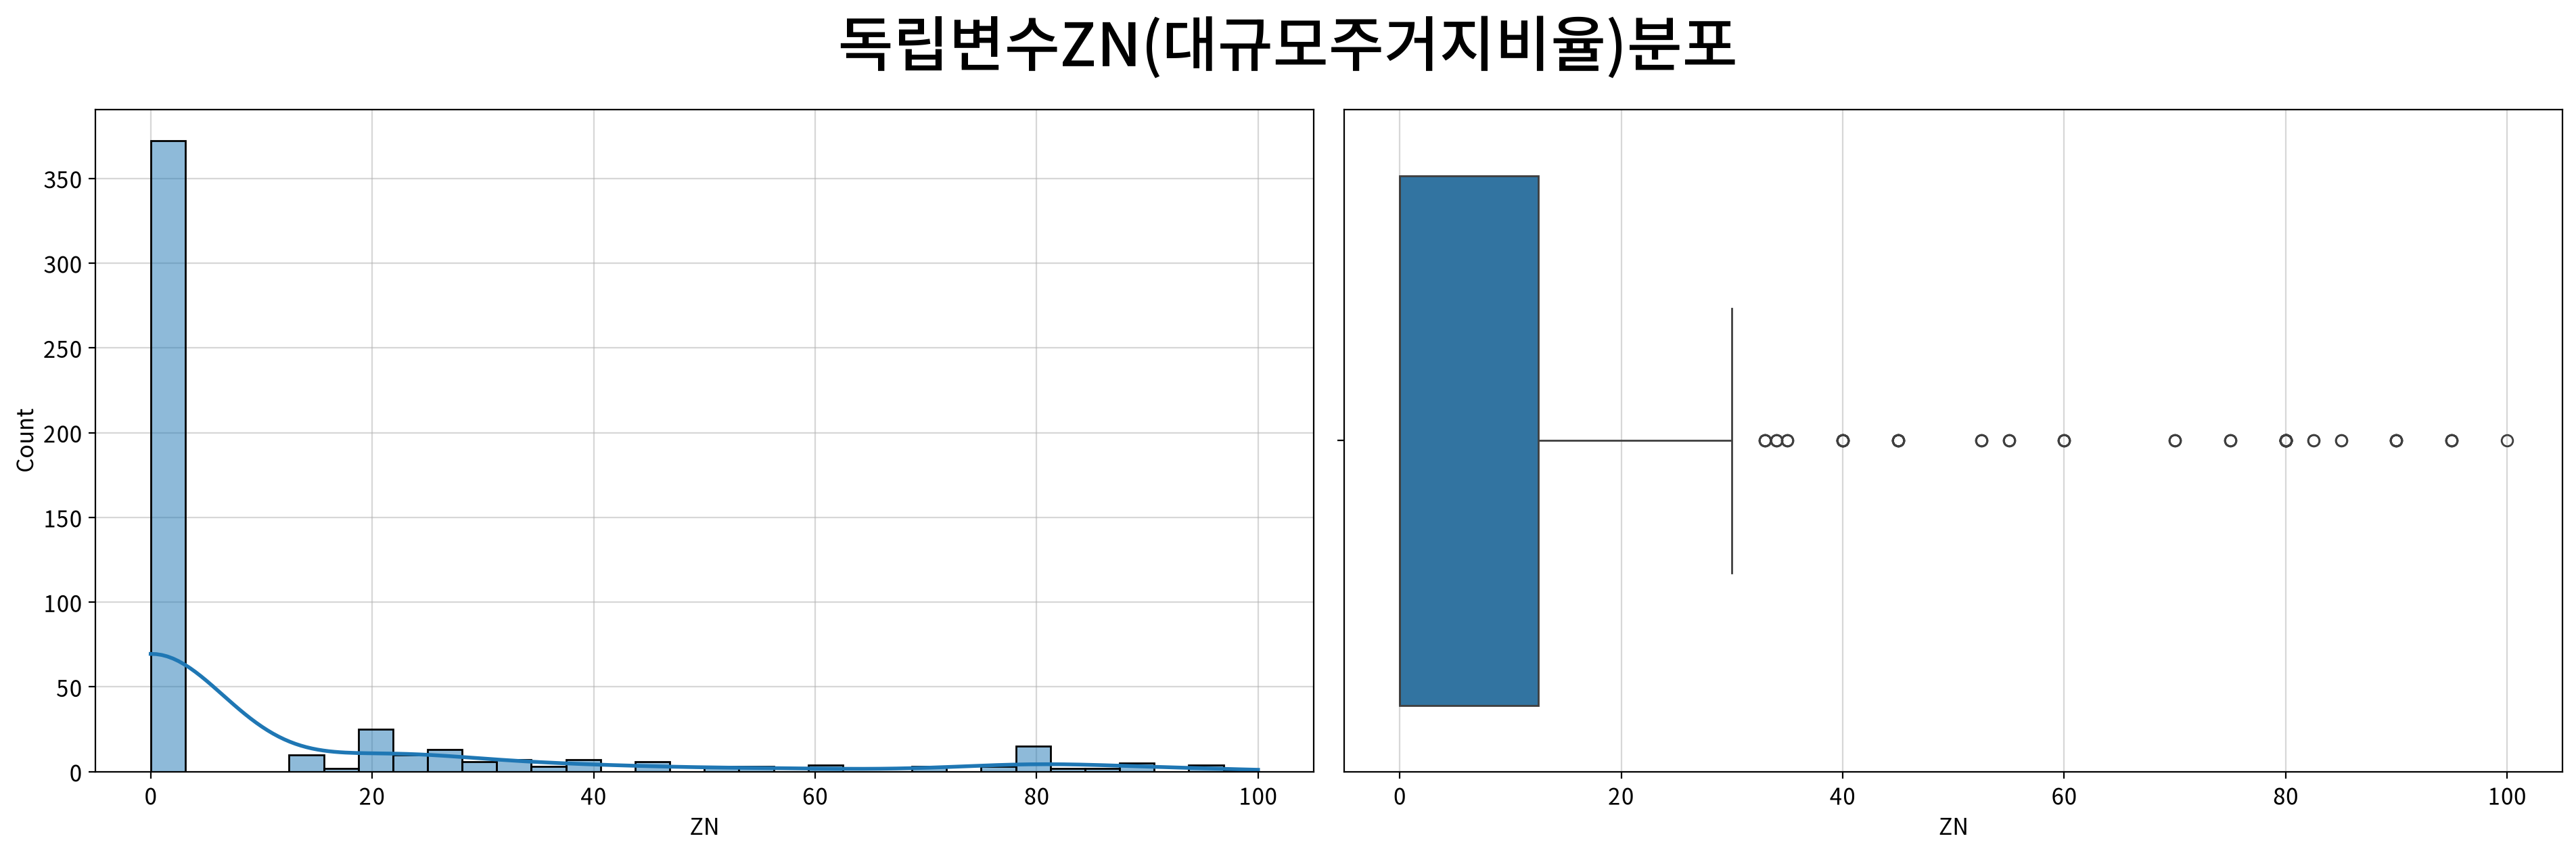

,ZN
count,506.000
mean,11.364
std,23.322
min,0.000
25%,0.000
50%,0.000
75%,12.500
max,100.000
rel_diff,inf
rdiff_flag,large_diff


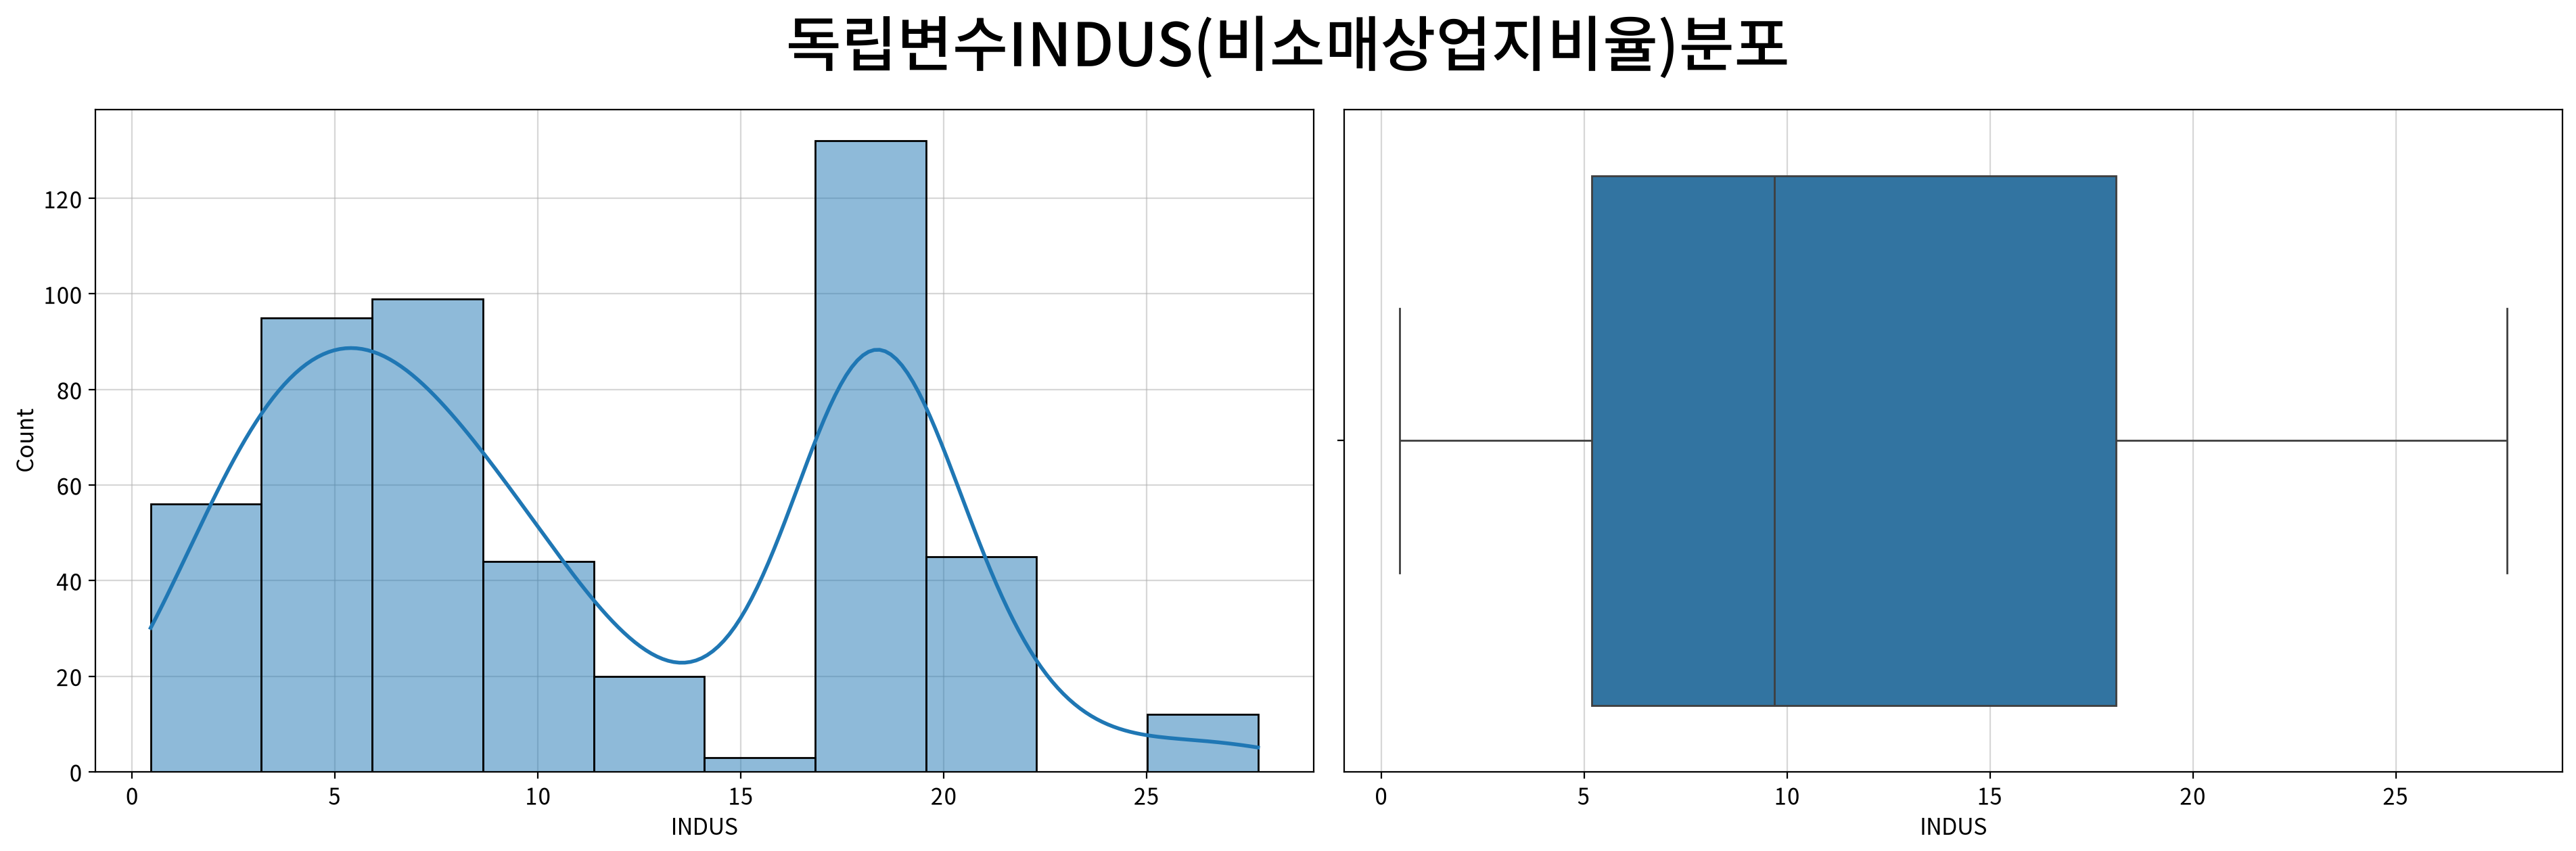

,INDUS
count,506.000
mean,11.137
std,6.860
min,0.460
25%,5.190
50%,9.690
75%,18.100
max,27.740
rel_diff,0.149
rdiff_flag,diff


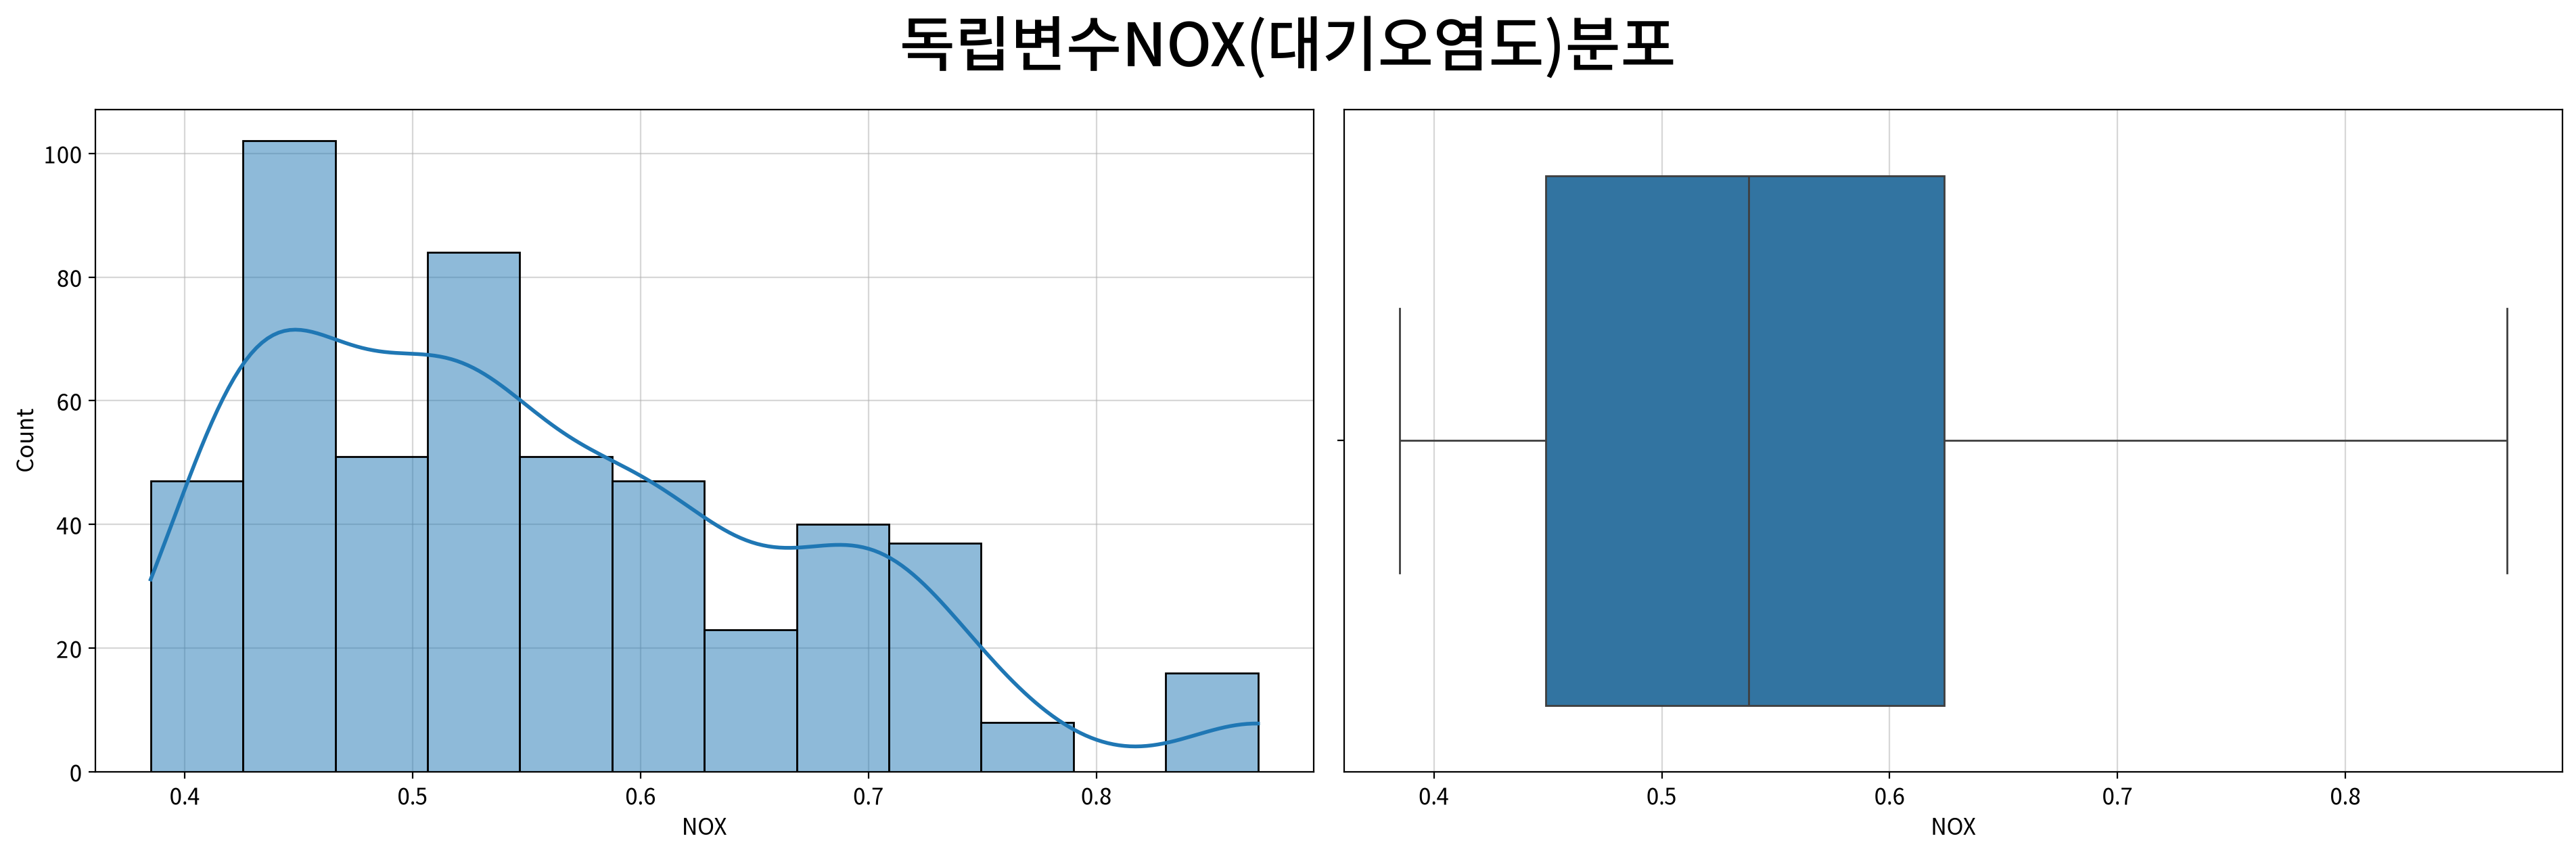

,NOX
count,506.000
mean,0.555
std,0.116
min,0.385
25%,0.449
50%,0.538
75%,0.624
max,0.871
rel_diff,0.031
rdiff_flag,similar


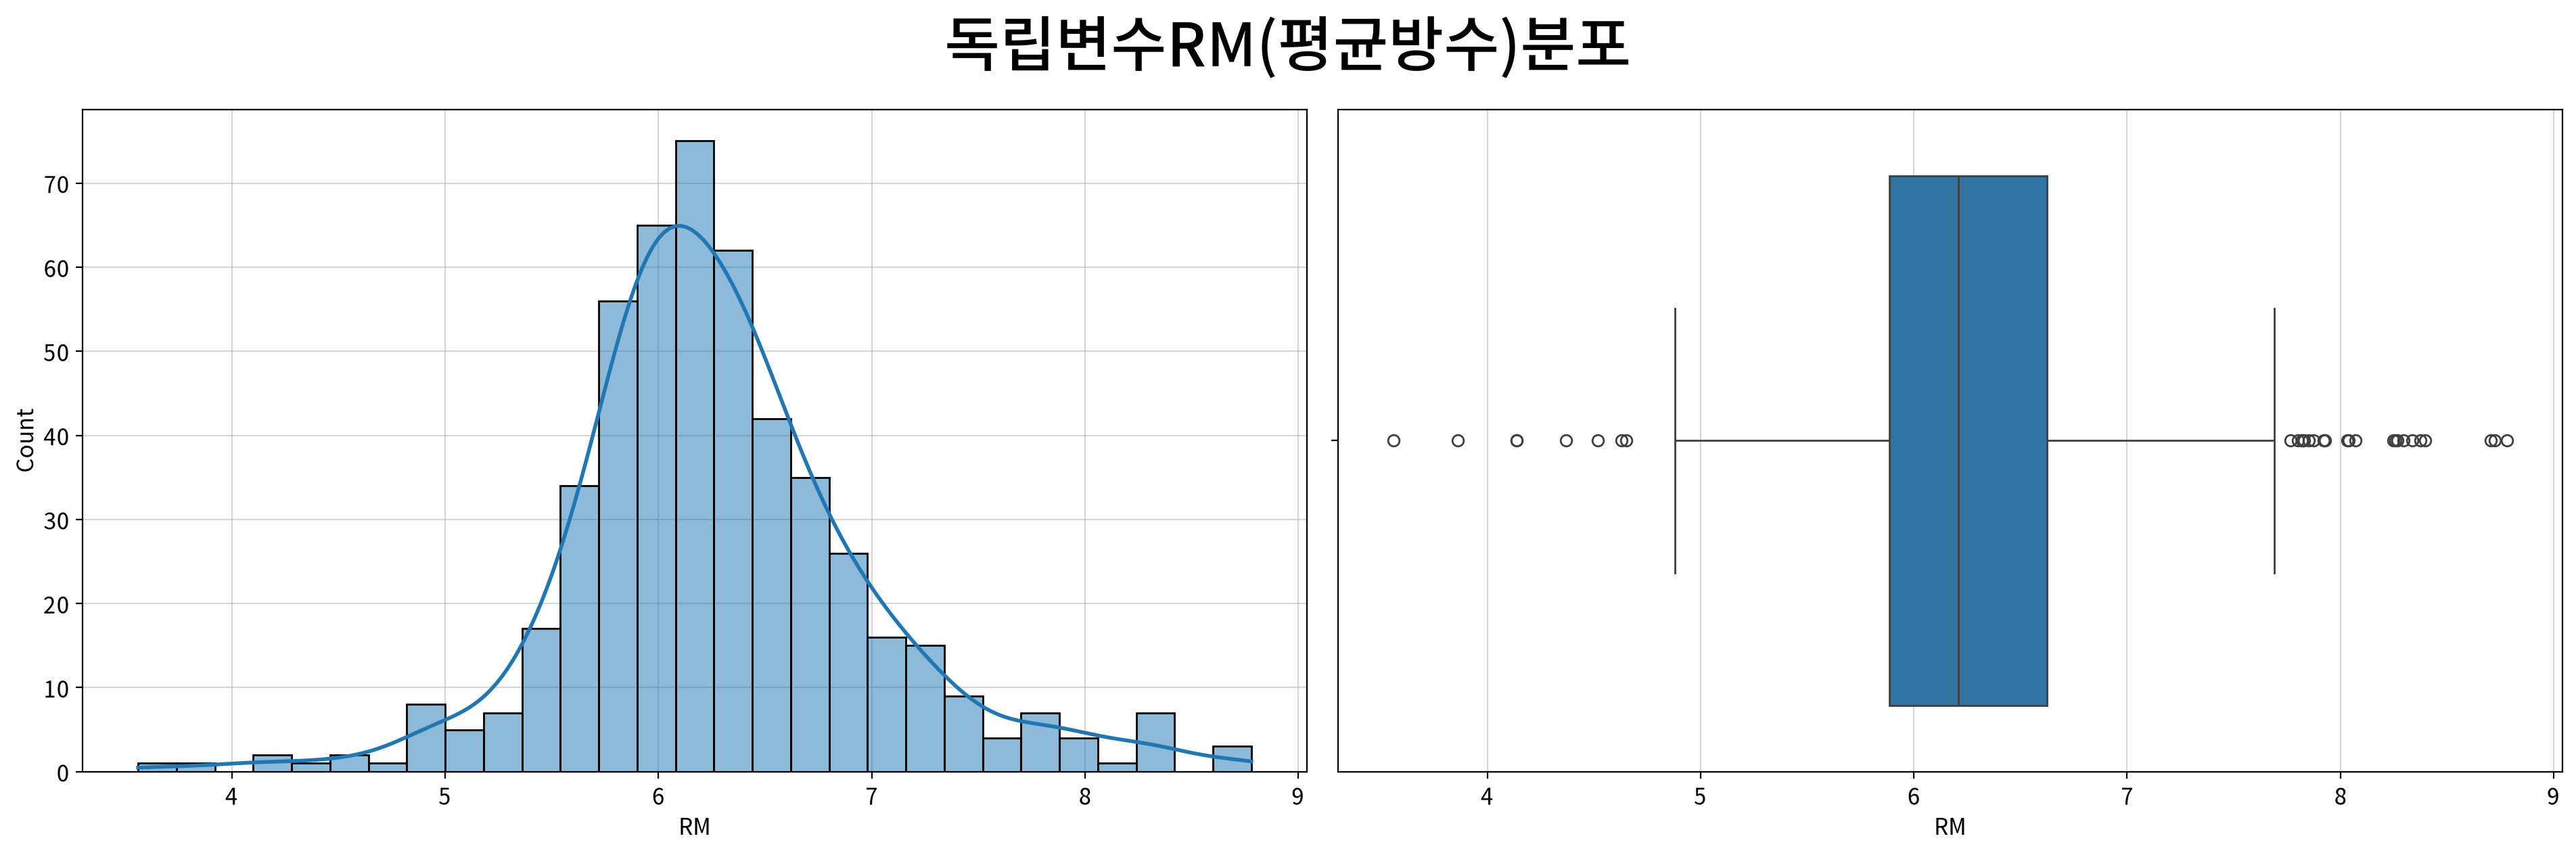

,RM
count,506.000
mean,6.285
std,0.703
min,3.561
25%,5.885
50%,6.208
75%,6.623
max,8.780
rel_diff,0.012
rdiff_flag,similar


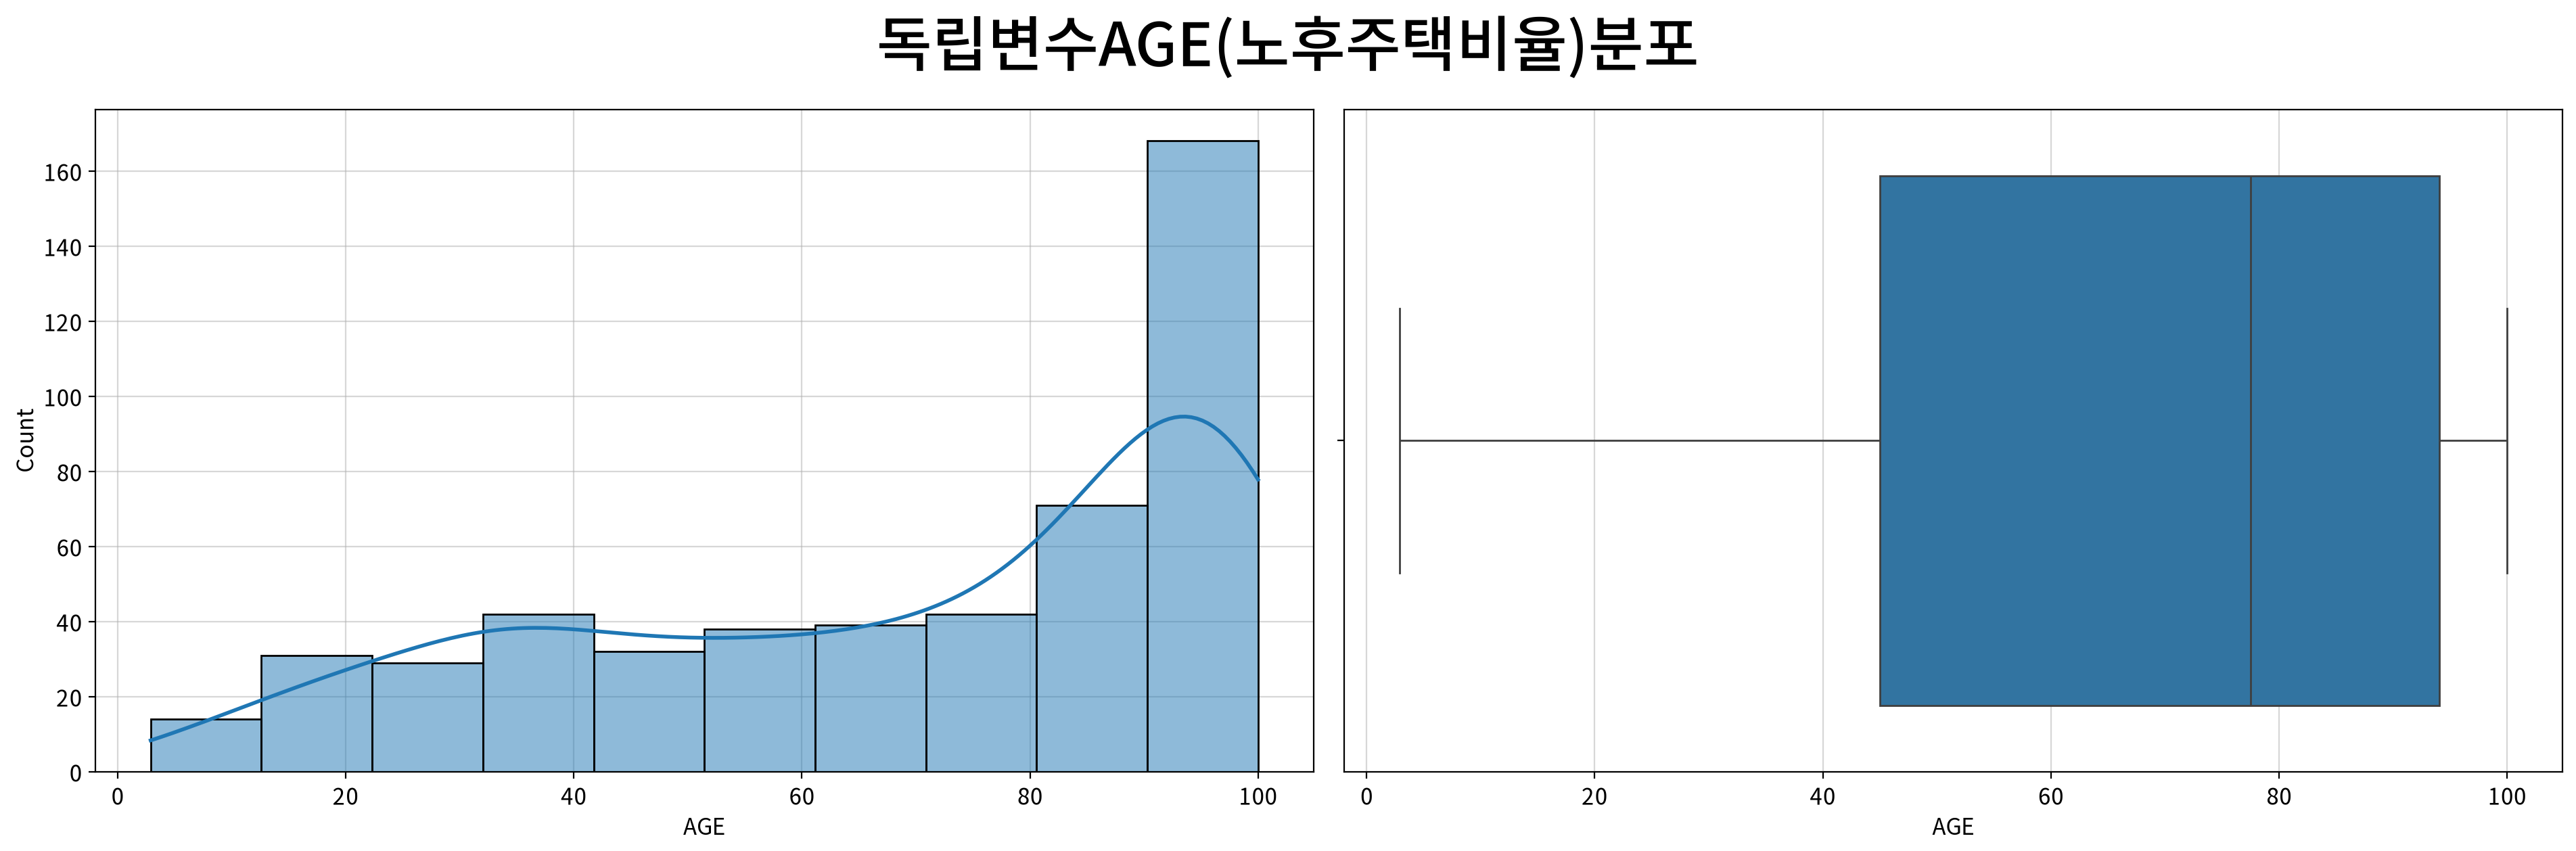

,AGE
count,506.000
mean,68.575
std,28.149
min,2.900
25%,45.025
50%,77.500
75%,94.075
max,100.000
rel_diff,0.115
rdiff_flag,diff


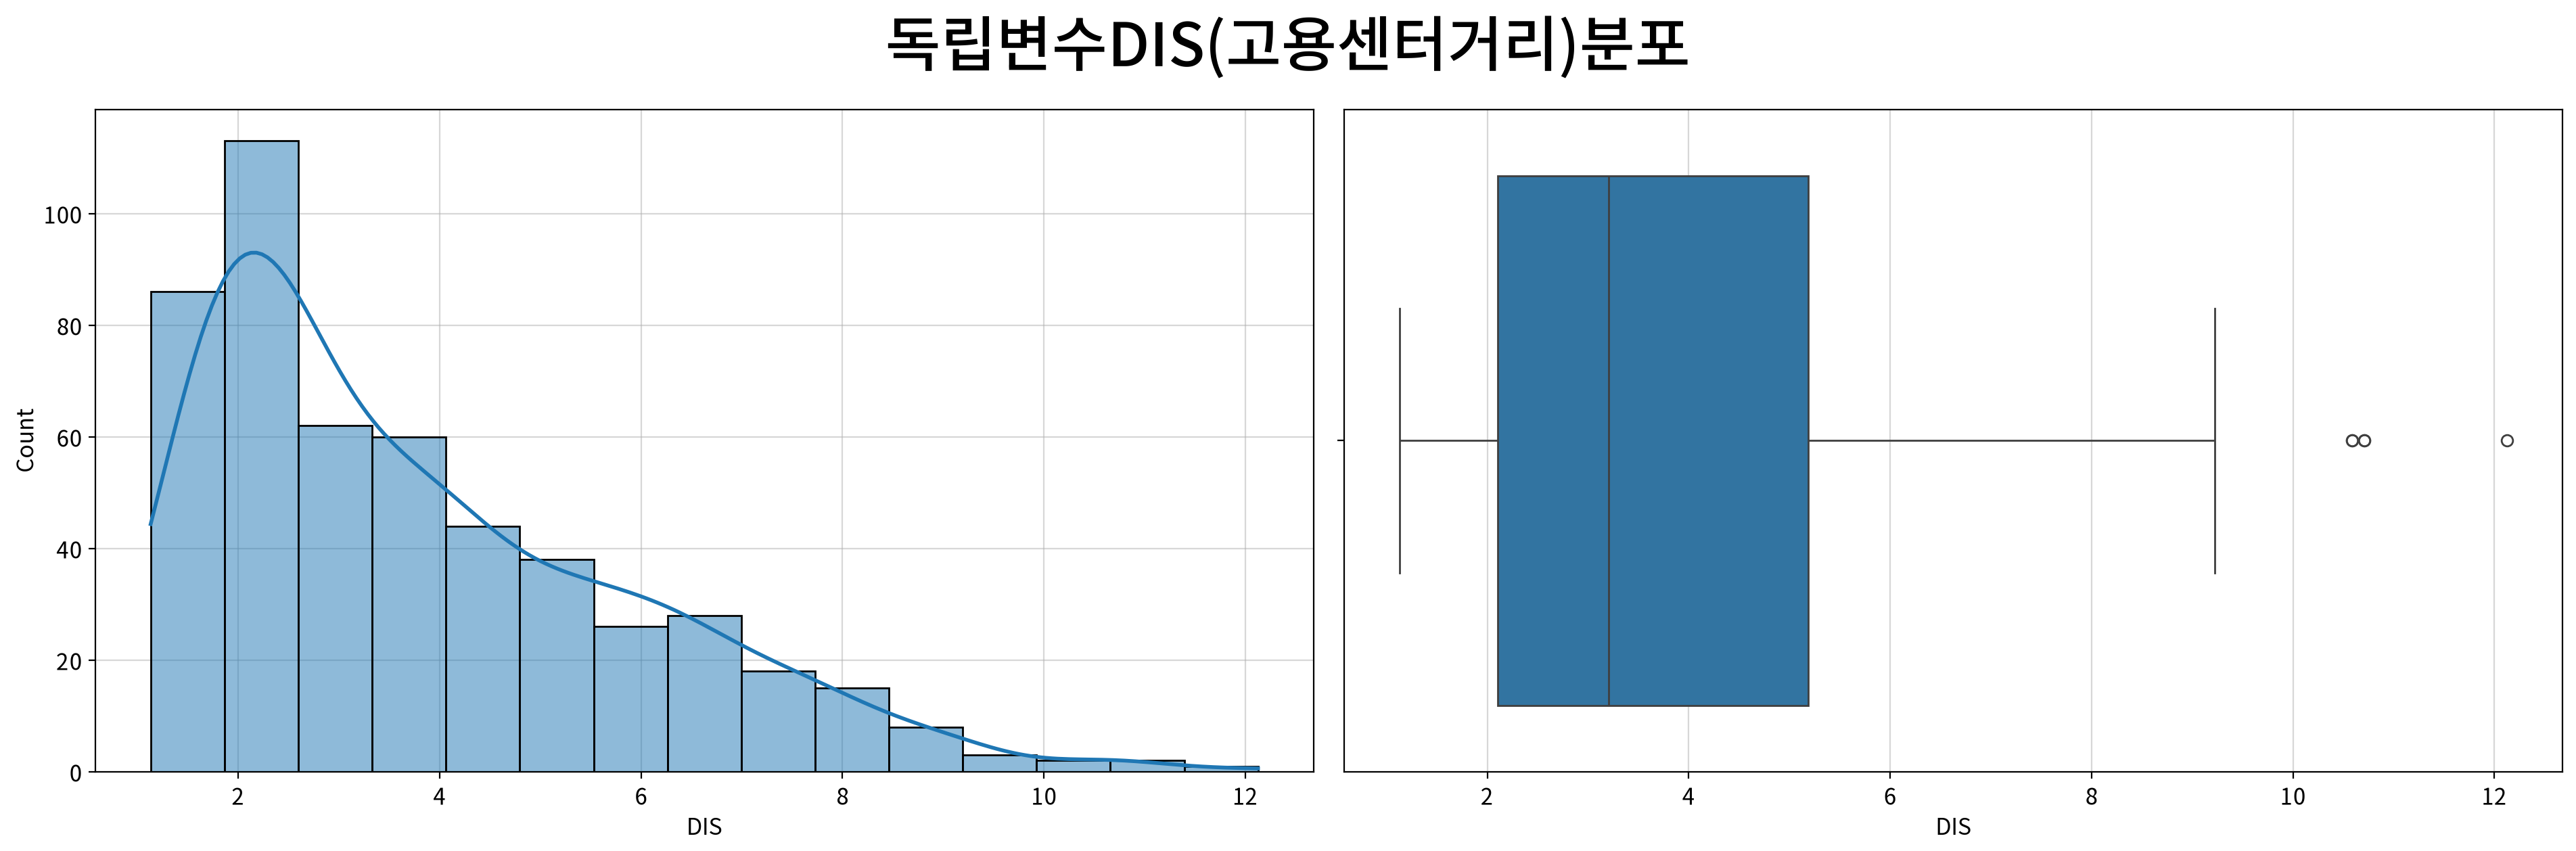

,DIS
count,506.000
mean,3.795
std,2.106
min,1.130
25%,2.100
50%,3.207
75%,5.188
max,12.127
rel_diff,0.183
rdiff_flag,diff


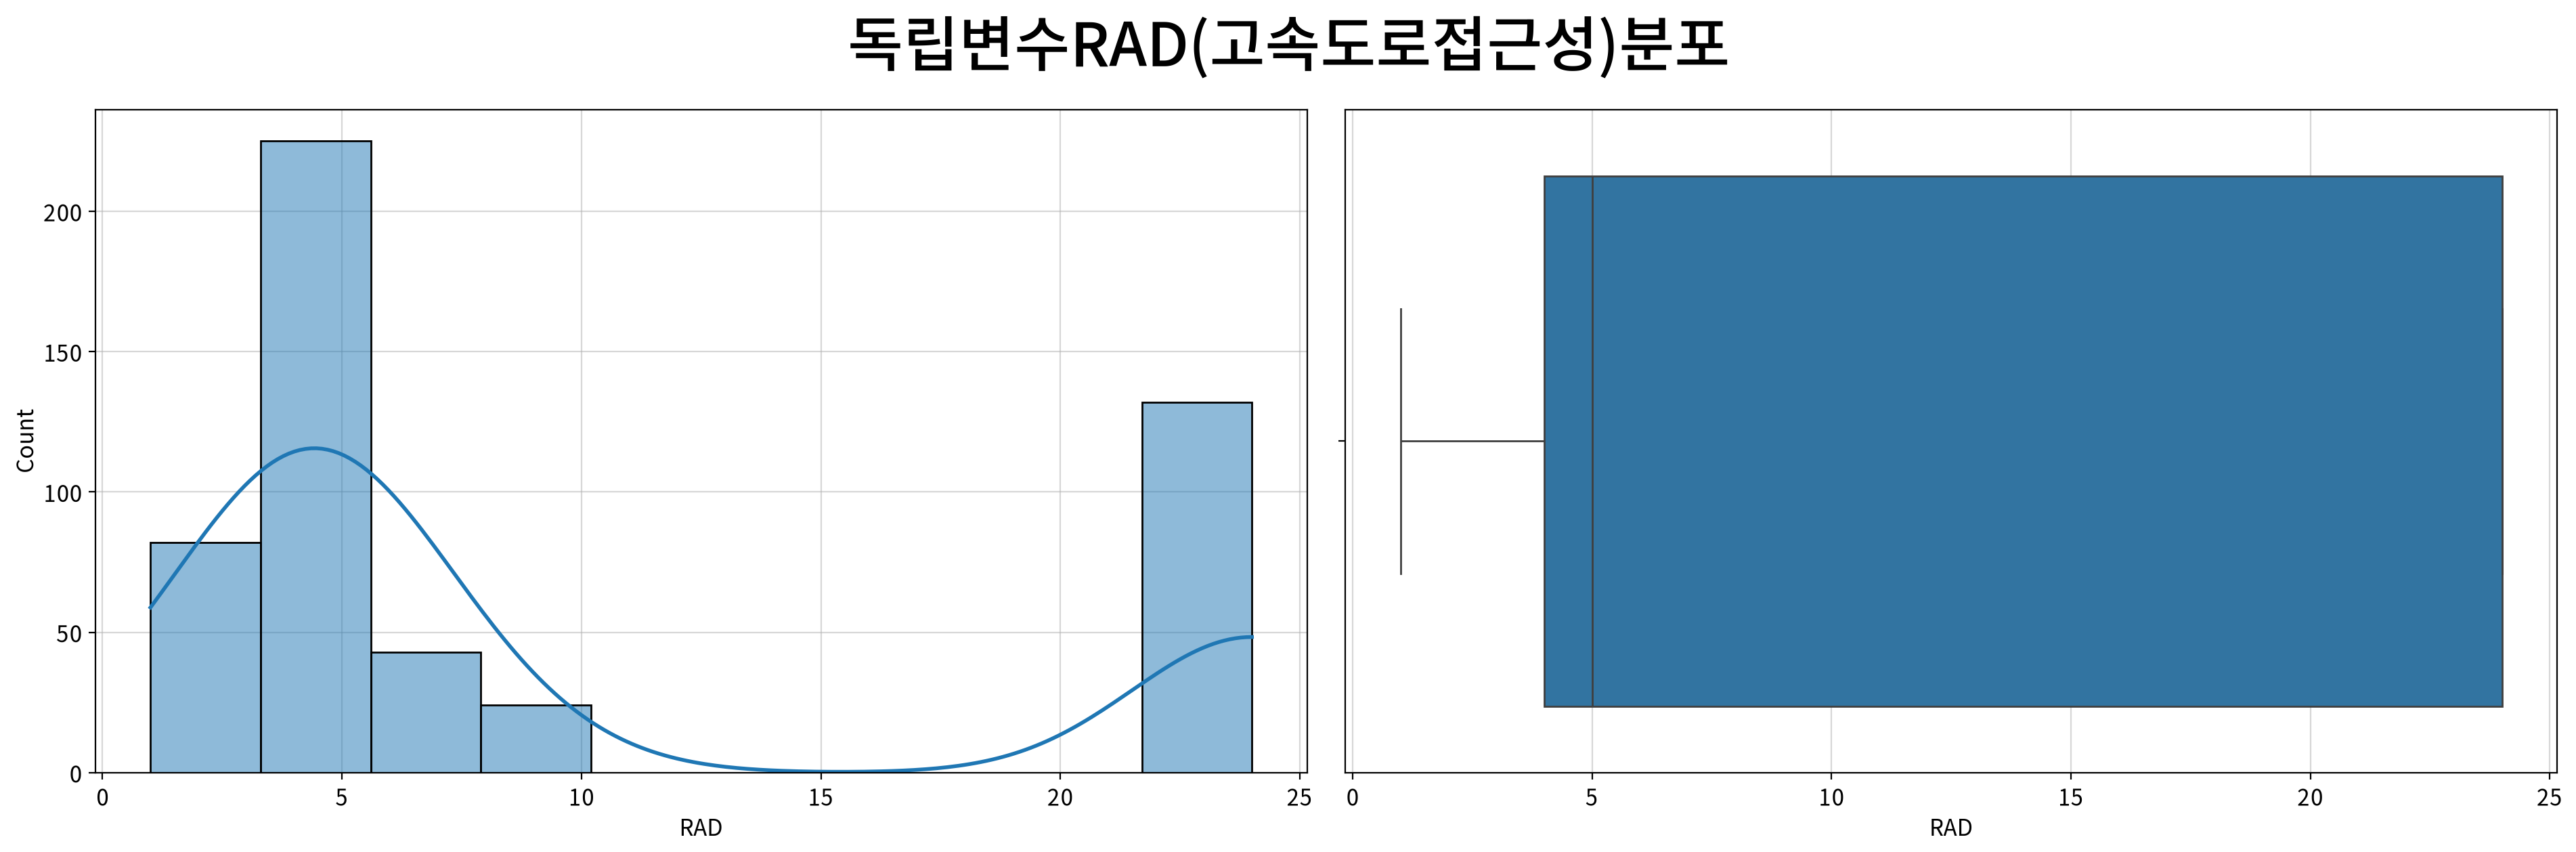

,RAD
count,506.000
mean,9.549
std,8.707
min,1.000
25%,4.000
50%,5.000
75%,24.000
max,24.000
rel_diff,0.910
rdiff_flag,large_diff


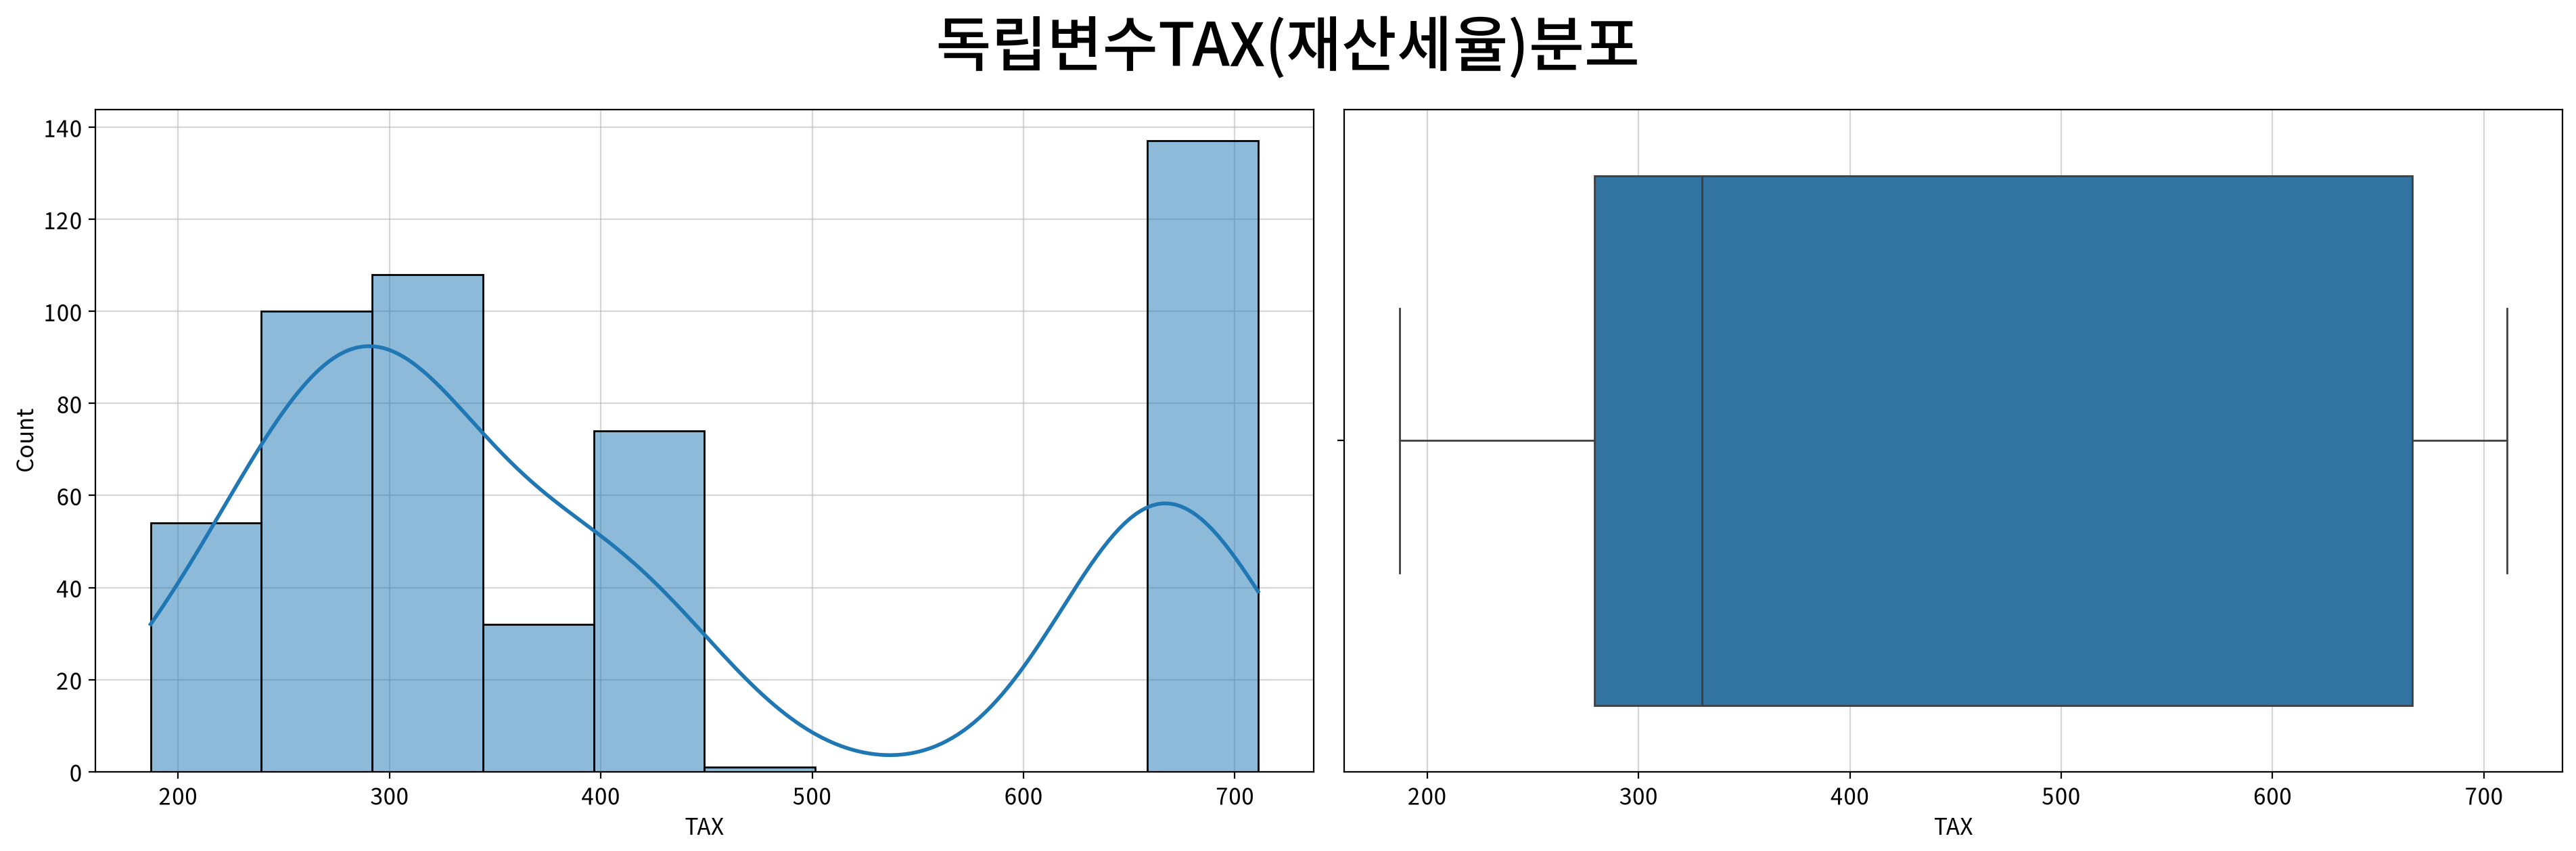

,TAX
count,506.000
mean,408.237
std,168.537
min,187.000
25%,279.000
50%,330.000
75%,666.000
max,711.000
rel_diff,0.237
rdiff_flag,diff


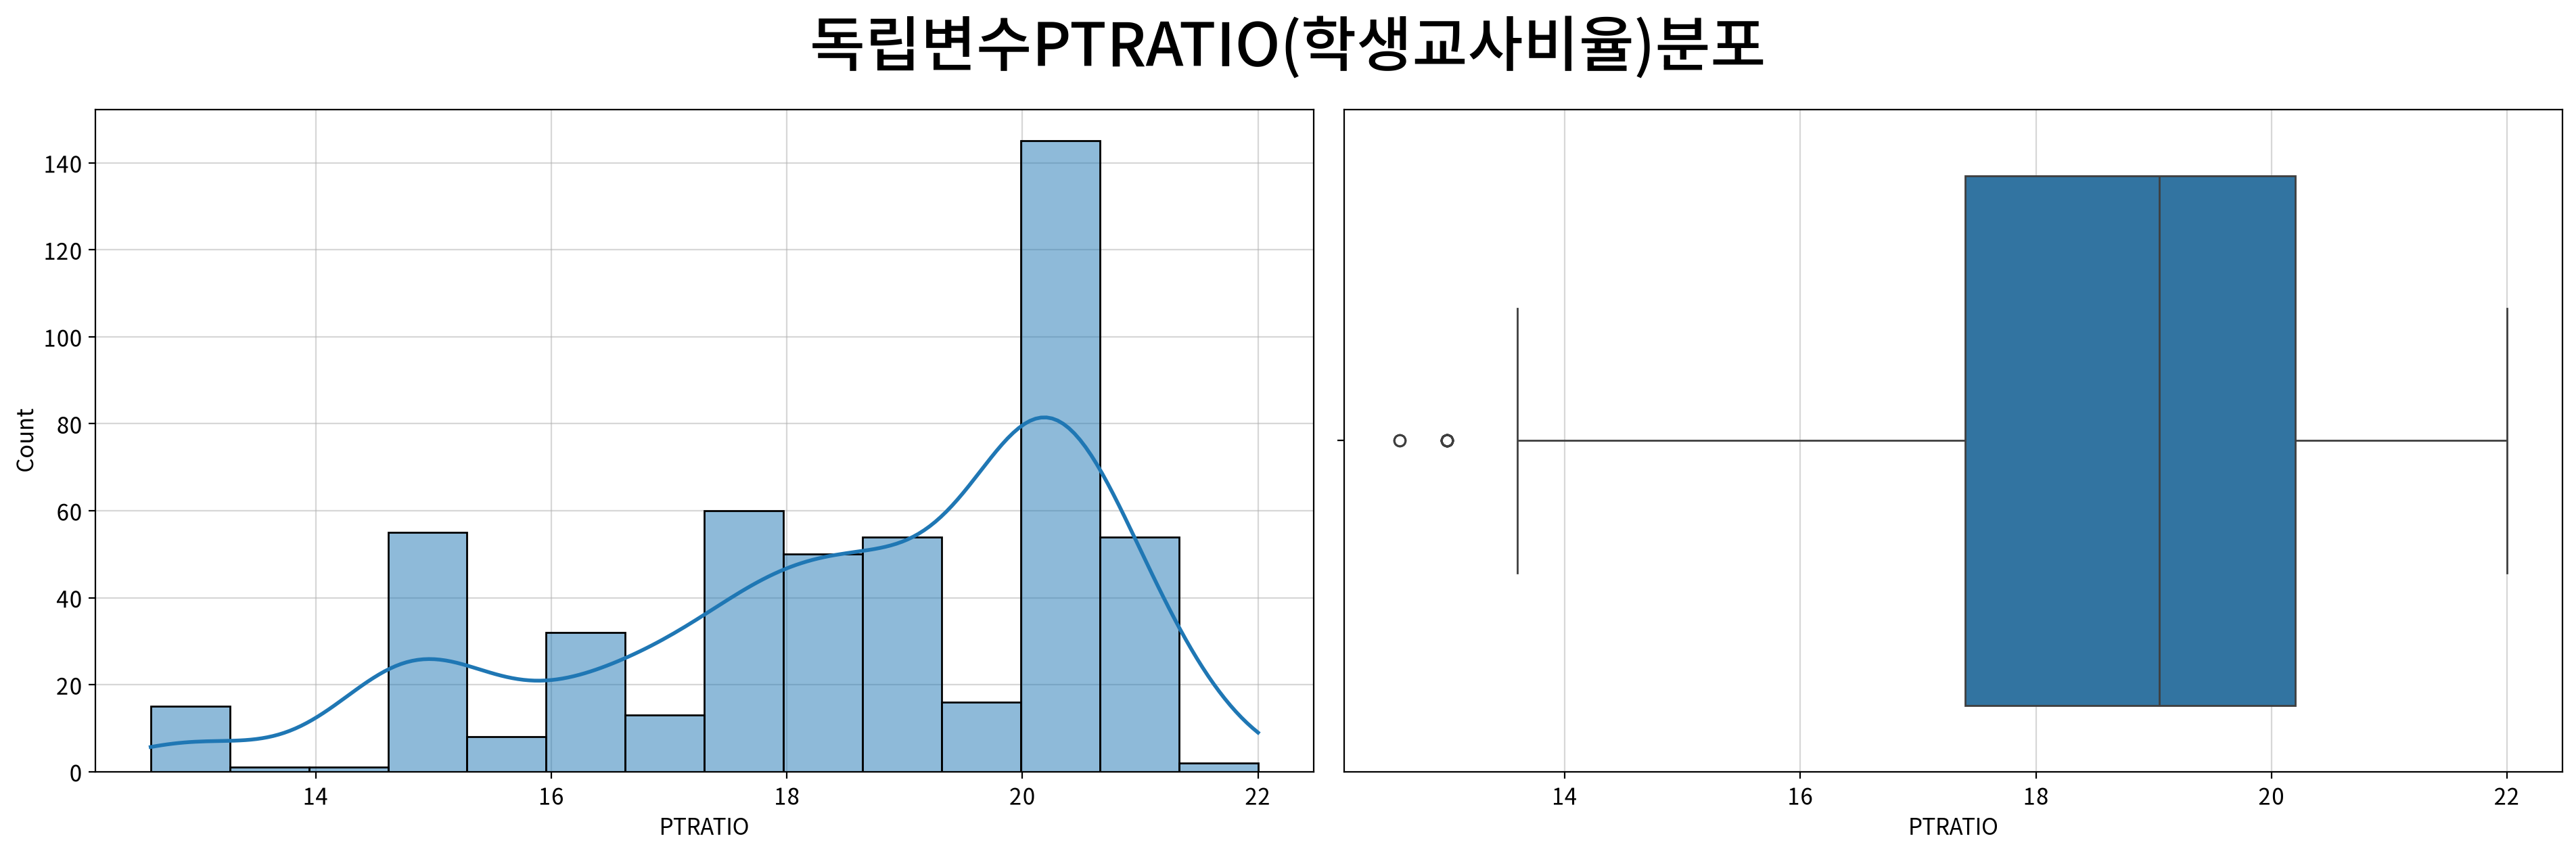

,PTRATIO
count,506.000
mean,18.456
std,2.165
min,12.600
25%,17.400
50%,19.050
75%,20.200
max,22.000
rel_diff,0.031
rdiff_flag,similar


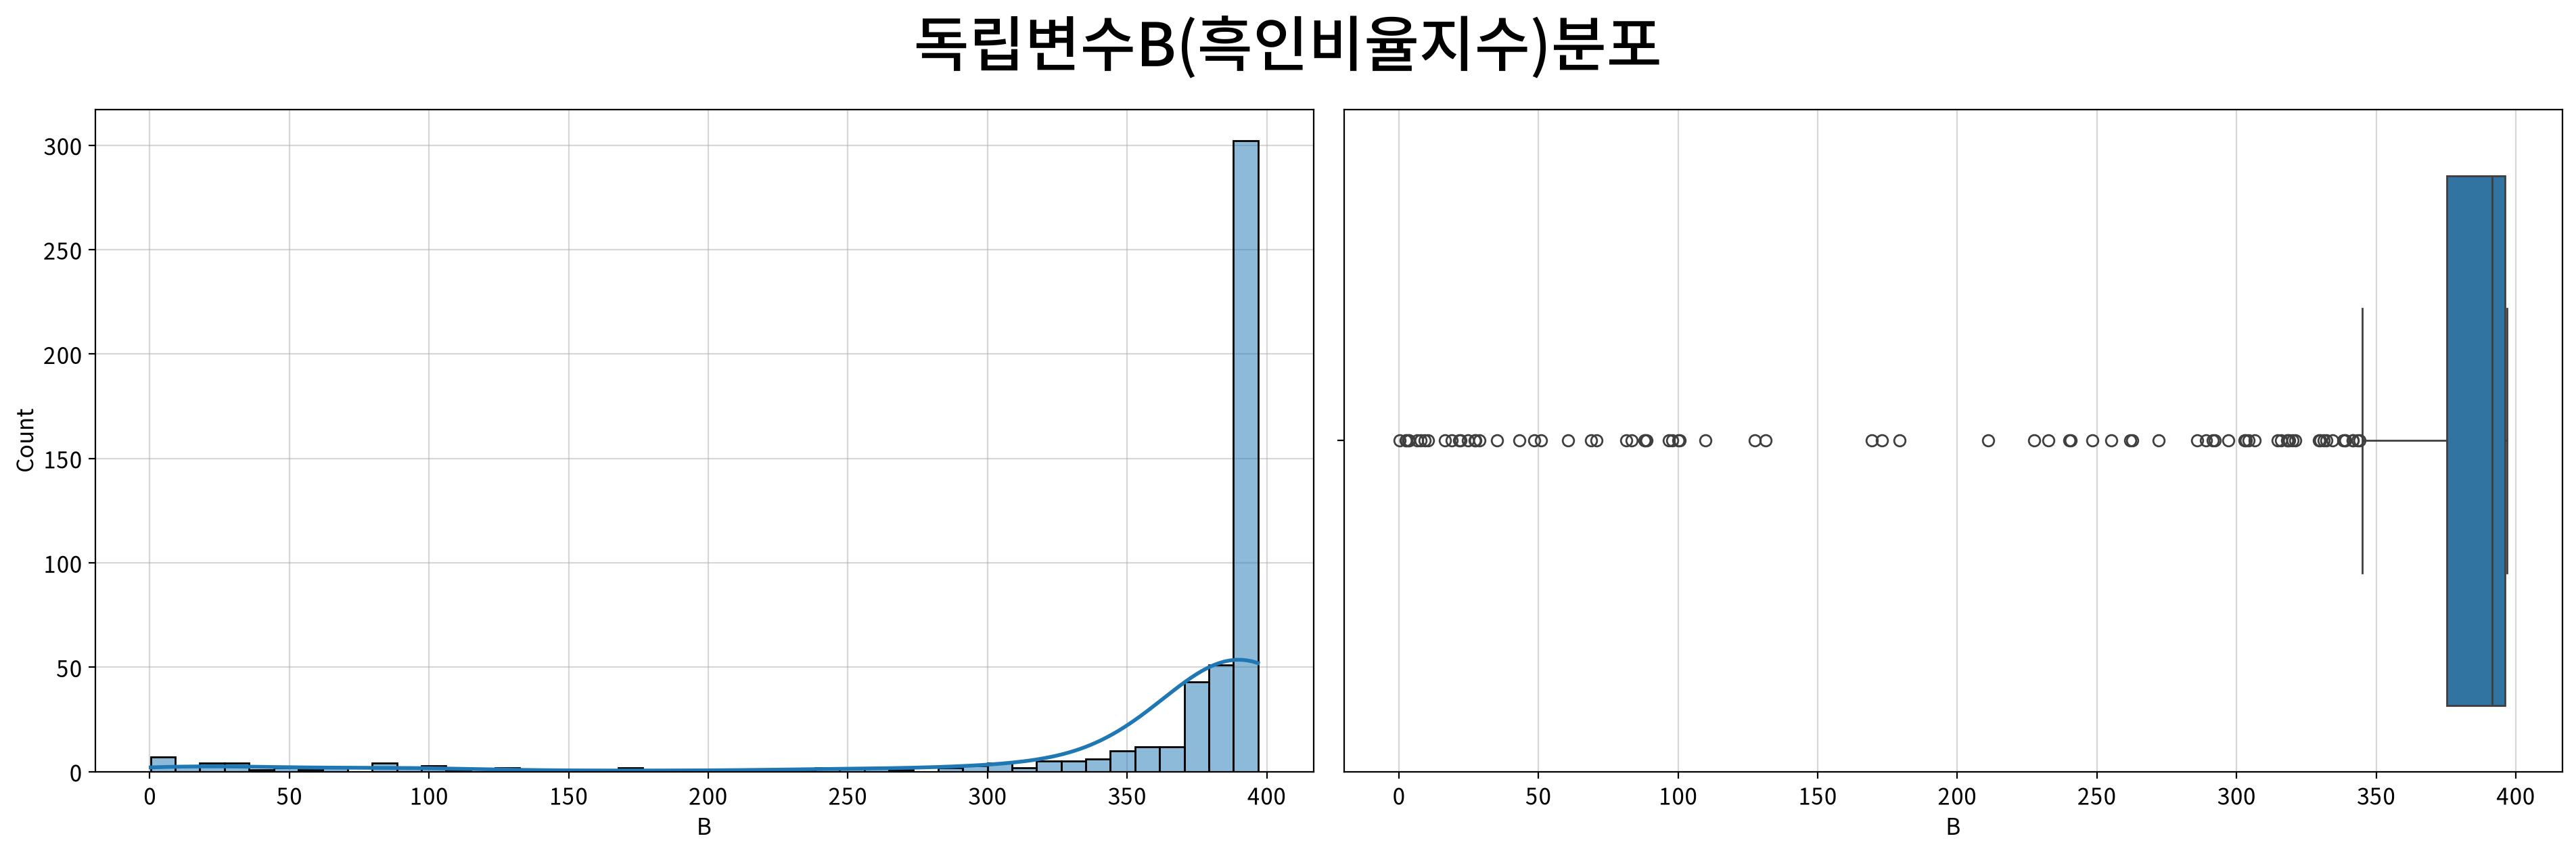

,B
count,506.000
mean,356.674
std,91.295
min,0.320
25%,375.377
50%,391.440
75%,396.225
max,396.900
rel_diff,0.089
rdiff_flag,similar


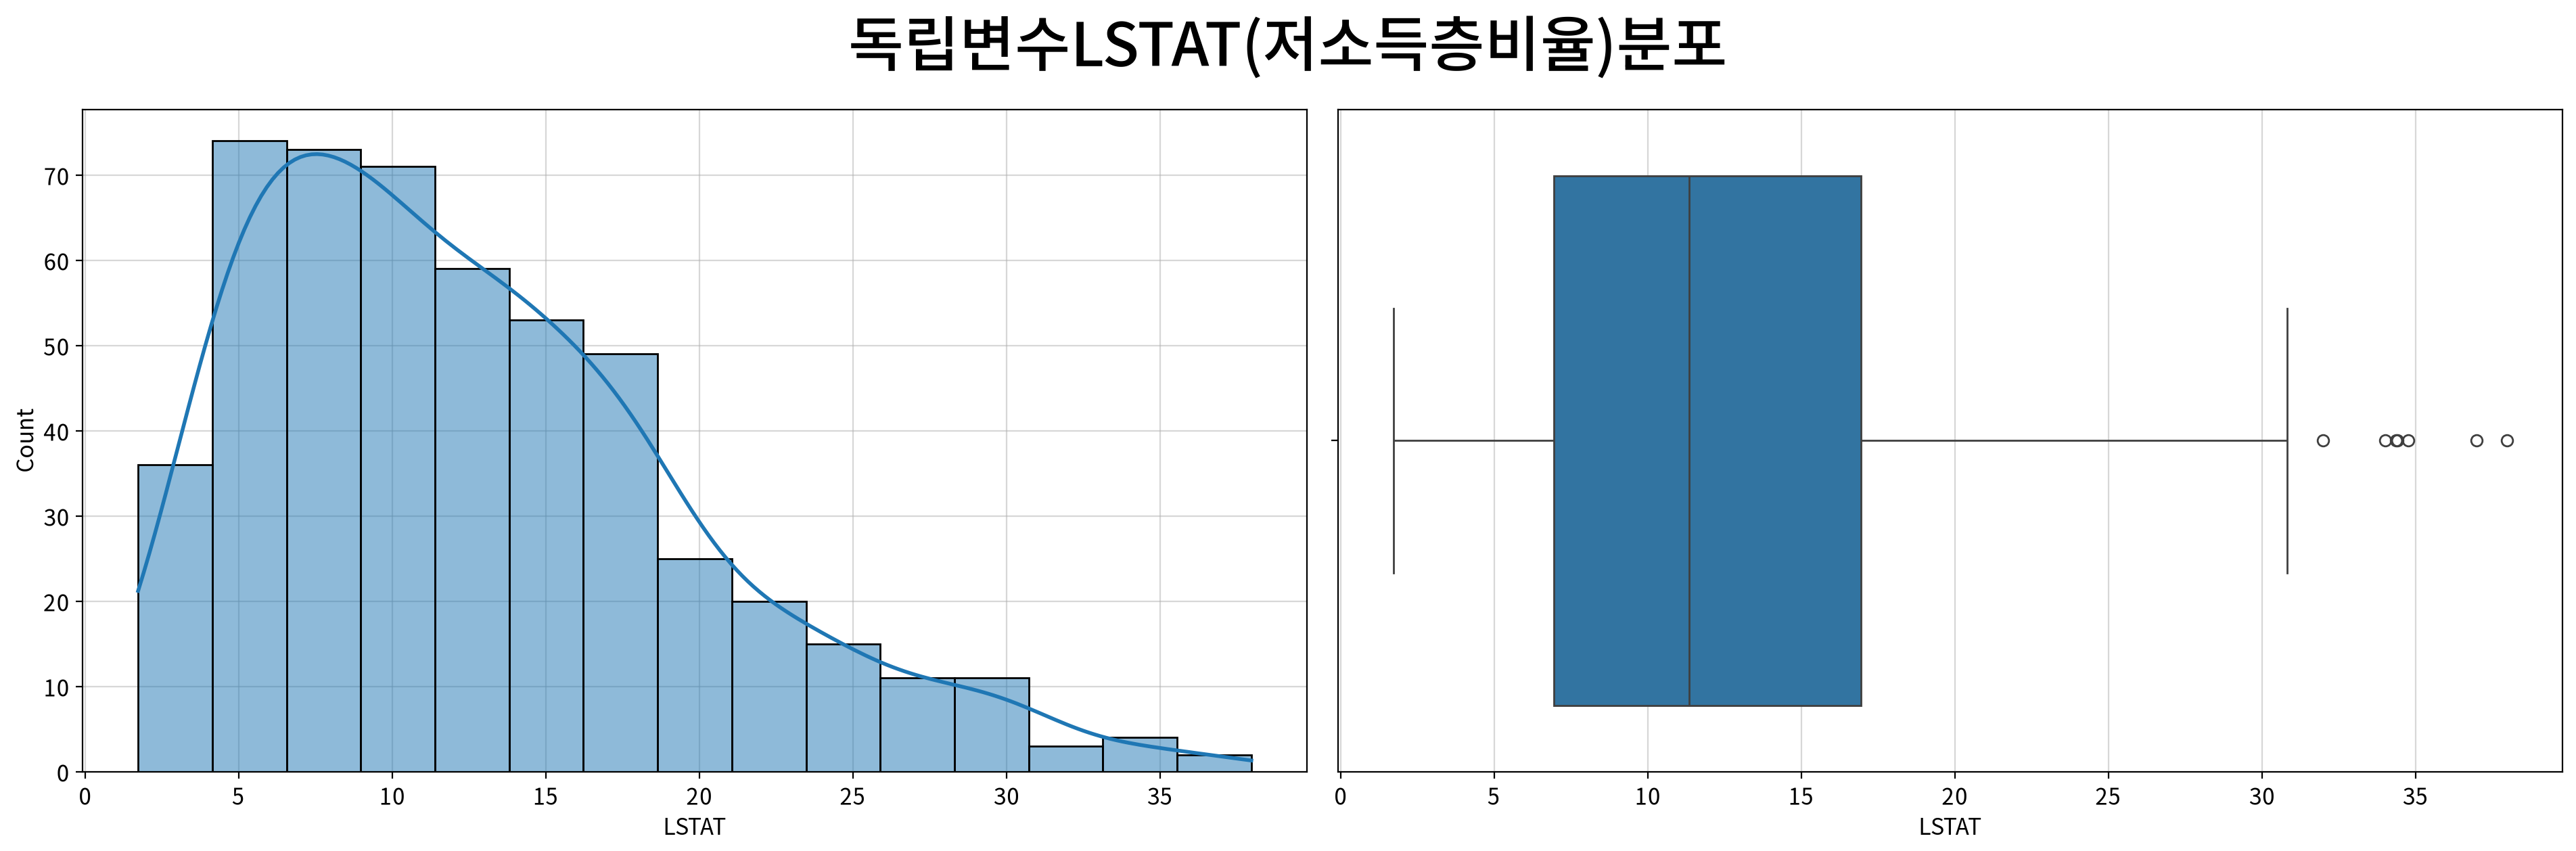

,LSTAT
count,506.000
mean,12.653
std,7.141
min,1.730
25%,6.950
50%,11.360
75%,16.955
max,37.970
rel_diff,0.114
rdiff_flag,diff


In [13]:
for i in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640, title=f'독립변수{i}({column_means[i]})분포')
    my_plot.histplot(data=df, x=i, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=i, ax=ax[1])
    my_plot.show()

    display(desc[desc.index == i].T)

#### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 | 이상치 | 이산점·군집 | 판단·조치 |
|---|---|---|---|---|---|
| `CRIM` | 매우 강한 우편향 | 단봉(0 근처 집중) | 많음(약 13%) | 0 값에 집중 | 로그 변환 + 이상치 처리 |
| `ZN` | 강한 우편향 | 0에 큰 덩어리 | 많음(약 13%) | 0 값에 집중 | 로그 변환 + 이상치 처리 |
| `INDUS` | 대칭에 가까움 | 다봉(쌍봉 경향) | 거의 없음 | 특정 구간 군집 | 변환 불필요, 다봉만 유의 |
| `NOX` | 약한 우편향 | 다봉 경향 | 없음 | — | 그대로 사용 가능 |
| `RM` | 대칭(정규에 가까움) | 단봉 | 양쪽에 소수 | — | 그대로 사용 가능 |
| `AGE` | 좌편향 | 단봉(100 쪽 몰림) | 없음 | 100 부근 집중 | 그대로 사용 가능 |
| `DIS` | 우편향 | 단봉 | 소수 | — | 로그 변환 고려 |
| `RAD` | 우편향 | **뚜렷한 이봉** | 없음 | **24에 큰 군집** | 사실상 범주형 → 선형 가정 주의 |
| `TAX` | 우편향 | **이봉** | 없음 | **666~711에 군집** | 사실상 범주형 → 선형 가정 주의 |
| `PTRATIO` | 좌편향 | 다봉(값 군집) | 소수 | 특정 값에 집중 | 그대로 사용 가능 |
| `B` | 매우 강한 좌편향 | 단봉(396 쪽 몰림) | 많음(약 15%) | 396 부근 집중 | 역로그 변환 + 이상치 처리 |
| `LSTAT` | 우편향 | 단봉 | 소수 | — | 로그 변환 고려 |

### 2. 명목형 독립변수

- 명목형은 분포 모양·왜도 대신 **범주의 균형/불균형**을 점검하여 "그대로 검정/모델에 넣어도 되는가?"를 판단한다.

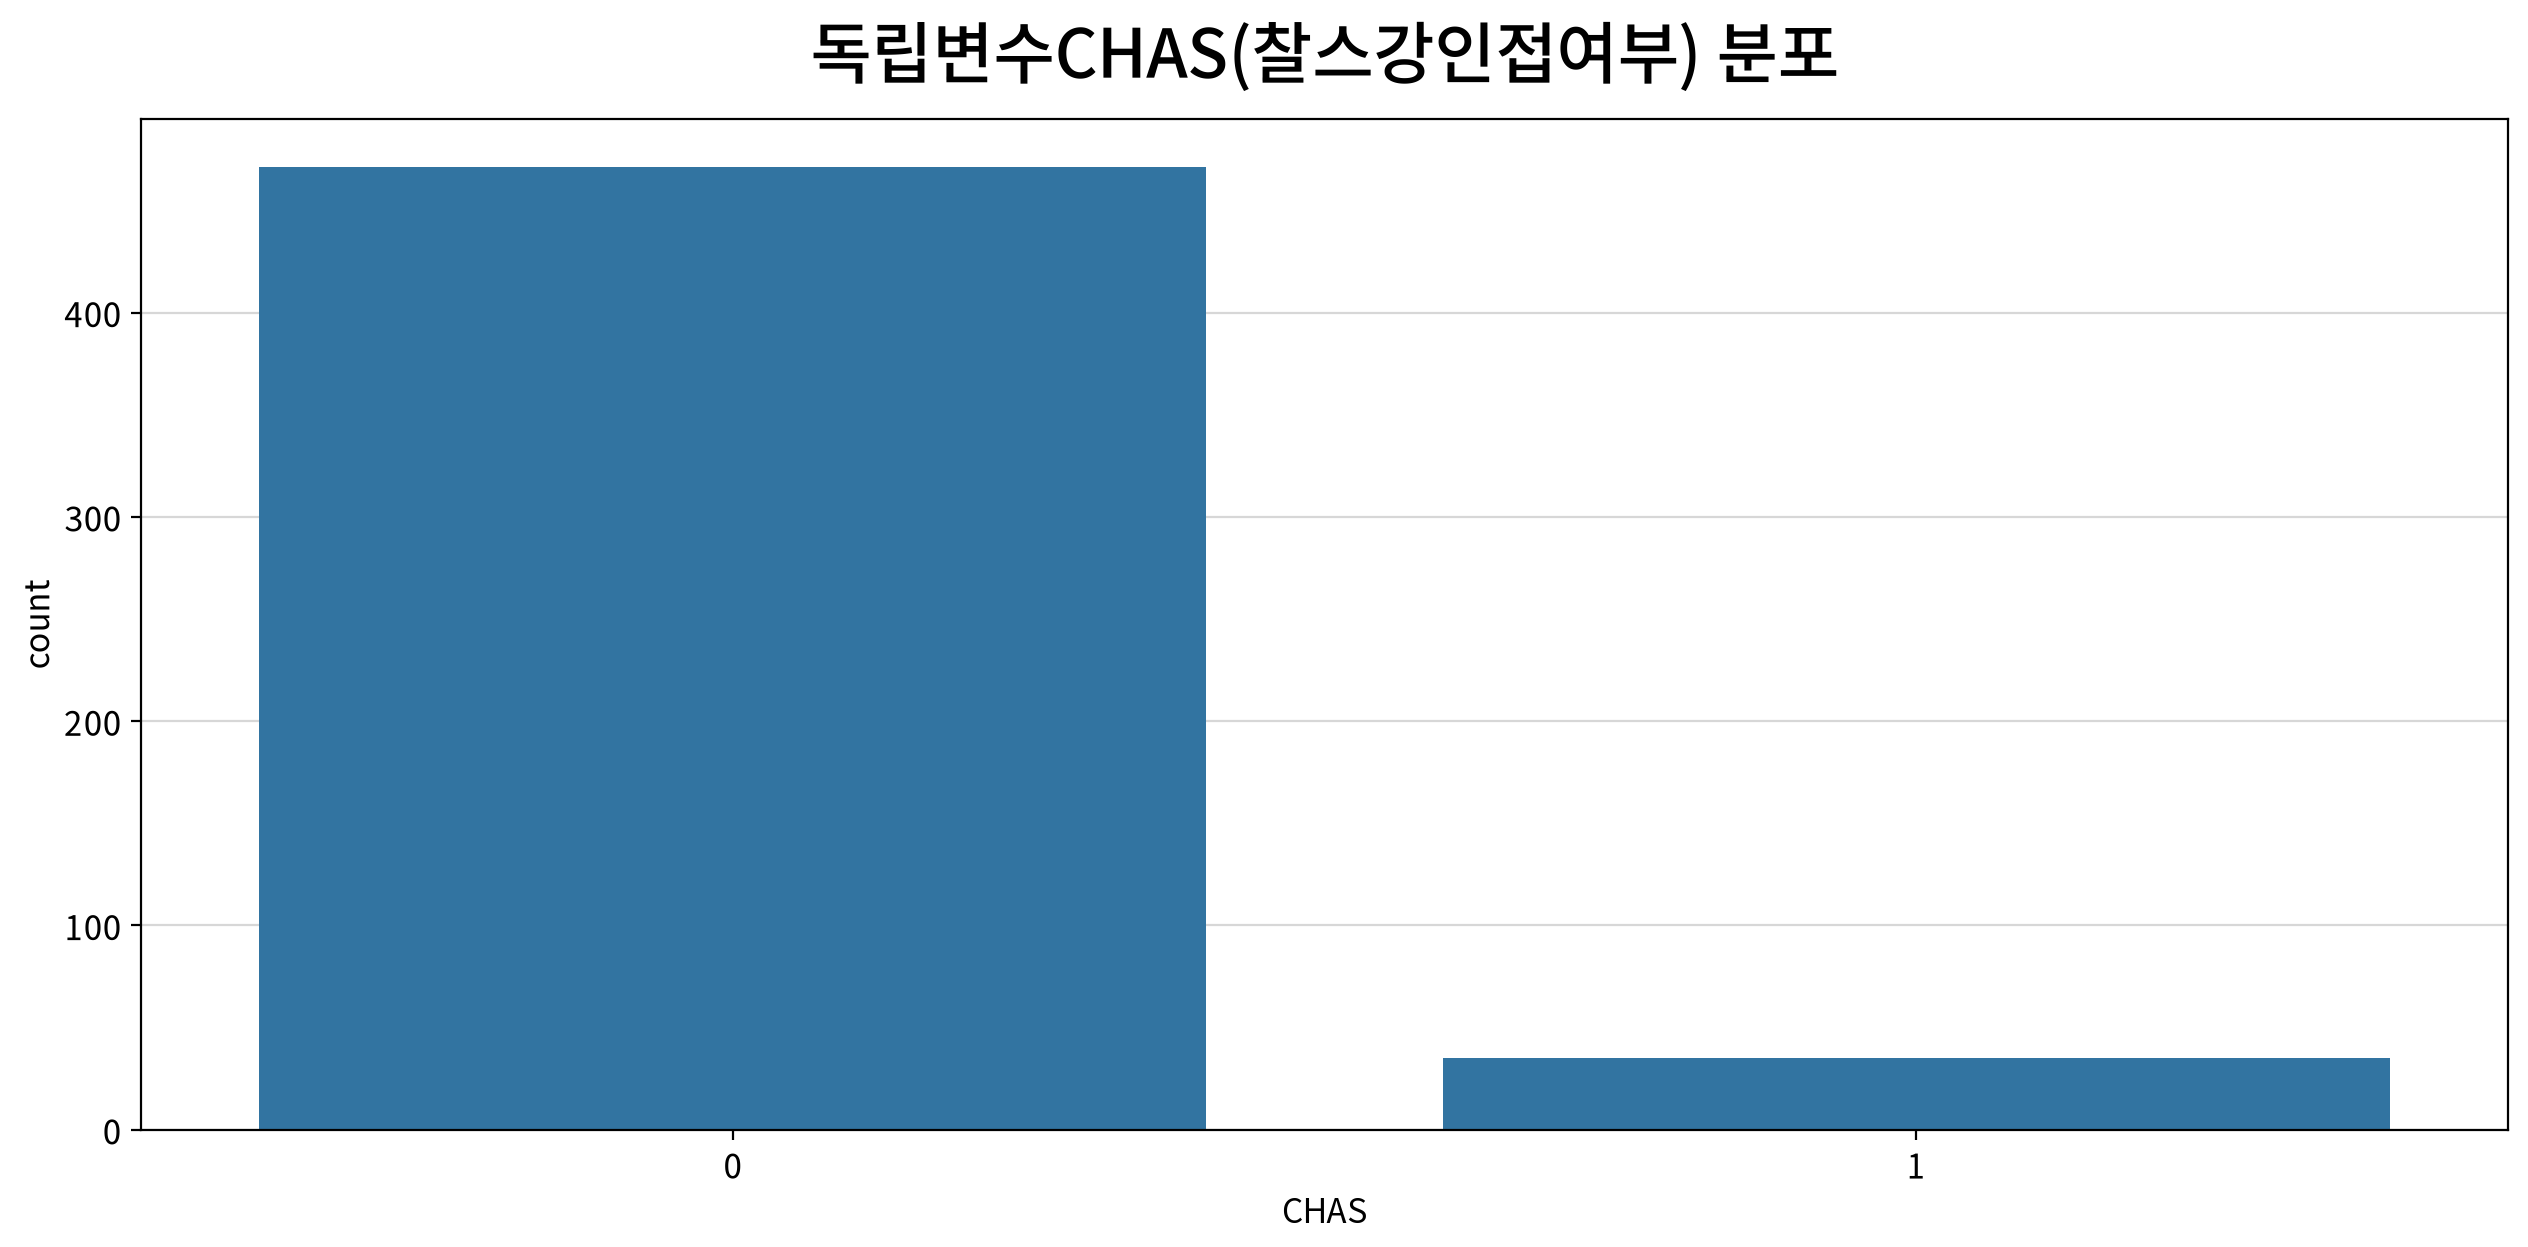

,count,unique,top,freq
CHAS,506,2,0,471


,빈도,비율
CHAS,,
0,471,0.931
1,35,0.069


In [14]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f'독립변수{n}({column_means[n]}) 분포')

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq['비율'] = df[n].value_counts(normalize=True)
    display(freq)

#### 💡 인사이트

| 변수 | 범주 수 | 빈도(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|
| `CHAS` | 2 (0=강변 아님, 1=강변 인접) | 0: 471 (93.1%) / 1: 35 (6.9%) | **심한 불균형** | 2집단이므로 `MEDV`와의 **T검정** 대상이나, 소수 집단(35건)이라 **비교·해석 신중** |

**판단·조치**
- `CHAS`는 2집단 명목형이므로 종속변수(`MEDV`)와의 차이는 **T검정**으로 확인한다.
- 다만 강변 인접(1) 집단이 35건(6.9%)뿐이라 **표본 불균형 → 검정력(power)이 낮고**, 모델 투입 시 소수 집단의 효과가 과소·과대 추정될 수 있어 **결과를 단정하지 말고 신중히 해석**한다.
- 소수 집단이라도 강변 인접이 가격에 유의미한 프리미엄을 주는지 검정으로 확인할 가치가 있으므로 **버리지 않고 유지**한다.